**Feature Selection Neden Önemli?**

**Overfitting (Aşırı Öğrenme) Önleme:** Gereksiz sütunlar, modelin veriyi ezberlemesine neden olur.

**Hız:** Daha az sütun, daha hızlı eğitim demektir.

**Anlaşılabilirlik:** "Ev fiyatını etkileyen en önemli 10 şey nedir?" sorusuna net cevap verebilmeni sağlar.

**1. Filter Methods (İstatistiksel Filtreleme)**

Modeli hiç karıştırmadan, sadece istatistiğe bakarsın.

**Constant Features:** Eğer bir sütundaki tüm değerler aynıysa (mesela tüm evlerin çatısı aynı malzemeyse), o sütun hiçbir şey anlatmaz. SİL!

***Quasi-constant Features:*** Verinin %99'u aynıysa (sadece 1-2 ev farklıysa), o da gereksizdir. SİL!

**Correlation (Korelasyon):** İki sütun birbirinin aynısıysa (örneğin hem "Metrekare" hem "Ayak Kare" varsa), birini silmelisin çünkü ikisi de aynı şeyi söylüyor.

**2. Wrapper Methods (Sarmalayıcı Yöntemler)**
Modeli bir döngüye sokarsın.

Modeli eğitirsin, en az işe yarayan sütunu atarsın, sonra tekrar eğitirsin. En iyi kadroyu bulana kadar denemeye devam edersin. (Biraz uzun sürer ama kalitelidir).

**3. Embedded Methods (Gömülü Yöntemler)***
Model eğitilirken hangi sütunun önemli olduğunu kendisi söyler.

**Lasso Regression (L1):** Gereksiz gördüğü sütunların katsayılarını doğrudan 0 yapar.

**Feature Importance:** Random Forest gibi ağaç modelleri, hangi sütunu ne kadar kullandığının raporunu verir.

In [1]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 7.7 MB/s eta 0:00:00


In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

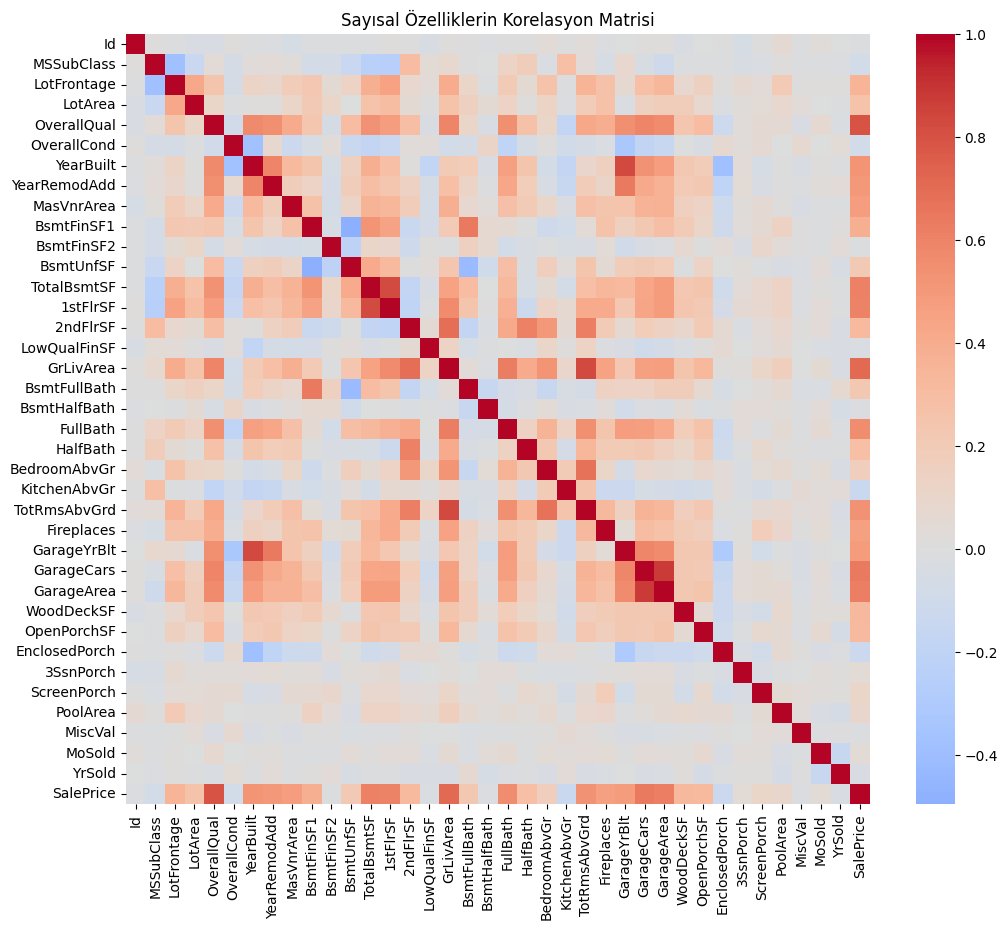

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sadece SAYISAL sütunları seçerek korelasyon hesapla
# numeric_only=True parametresi hayat kurtarır!
cor_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

# Korelasyonu 0.8'den yüksek olanları daha net görmek için bir eşik belirleyelim
sns.heatmap(cor_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Sayısal Özelliklerin Korelasyon Matrisi")
plt.show()

Eğer bir sütundaki tüm değerler aynıysa (örneğin 1460 evin hepsinde havuz yoksa ve o sütun hep 0 ise), bu sütun model için sadece bir yüktür.

In [6]:
from sklearn.feature_selection import VarianceThreshold

# Sadece sayısal sütunları alalım (Scaling yapılmış verin üzerinden gidebilirsin)
# Varyansı 0 olanları (yani tek bir değerden oluşanları) seçer
constant_filter = VarianceThreshold(threshold=0)
constant_filter.fit(df.select_dtypes(include=['number']))

VarianceThreshold(threshold=0)

In [7]:
# Sabit olmayan sütunları alalım
non_constant_cols = df.select_dtypes(include=['number']).columns[constant_filter.get_support()]
dropped_constant = [col for col in df.select_dtypes(include=['number']).columns if col not in non_constant_cols]

print(f"Silinen Sabit Sütunlar: {dropped_constant}")

Silinen Sabit Sütunlar: []


GarageCars vs GarageArea (0.88 korelasyon) -> GarageCars genellikle daha güçlüdür.

TotalBsmtSF vs 1stFlrSF (0.82 korelasyon)

TotRmsAbvGrd vs GrLivArea (0.83 korelasyon)

In [8]:
import numpy as np

# Korelasyon matrisini hesapla
corr_matrix = df[non_constant_cols].corr().abs()

# Sadece üst üçgeni al (matris simetrik olduğu için)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 0.80'den büyük olanları bul
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

print(f"Silinen Kopya Sütunlar: {to_drop}")

# Veriden çıkaralım
df.drop(columns=to_drop, inplace=True)

Silinen Kopya Sütunlar: ['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']


In [9]:
# SalePrice ile korelasyonu çok düşük olanları bulalım
price_corr = df.corr(numeric_only=True)['SalePrice'].abs()
weak_features = price_corr[price_corr < 0.05].index.tolist()

print(f"Çok Zayıf Sütunlar: {weak_features}")
df.drop(columns=weak_features, inplace=True)

Çok Zayıf Sütunlar: ['Id', 'BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', '3SsnPorch', 'MiscVal', 'MoSold', 'YrSold']
